# Fast AFT workflow from existing survival events

This notebook does not rerun raw-trade downloads, shock detection, or convergence calculations.

It:
1. loads your saved event files;
2. pulls only daily klines, funding rates, and Fear & Greed once;
3. caches those daily covariates;
4. merges them onto the events;
5. fits monthly AFT models.


In [26]:
from pathlib import Path
import sys
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BUNDLE_DIR = Path(".")
if str(BUNDLE_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR.resolve()))

from trade_data_pull import TradeData

from aft_fast_from_events import (
    FastAFTConfig,
    load_event_files,
    normalize_event_columns,
    merge_daily_covariates,
    fit_monthly_aft,
    summarize_stability,
    plot_coefficient_heatmap,
)


## 1. Paths and settings


In [27]:
ASSET = "btc"        # "btc" or "eth"
CM_UM = "cm"         # "um" or "cm"

EVENT_PATH = Path(f"./sa_{ASSET}_{CM_UM}/events")
OUTPUT_DIR = Path(f"./aft_results_{ASSET}_{CM_UM}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TICKER = f"{ASSET.upper()}USDT"
SOURCE = "Binance"
START = "20210101"
END = "20260101"

CONFIG = FastAFTConfig(
    distribution="loglogistic",
    resolution_pct=90,
    min_episodes=500,
    min_resolved=100,
    exclude_origins=("ambiguous",),
)

DAILY_CACHE = OUTPUT_DIR / f"{ASSET}_{CM_UM}_daily_covariates.parquet"


## 2. Find the monthly event files without loading them all

The notebook now processes one Parquet file at a time. It does not concatenate the full event history into memory.


In [28]:
EVENT_COLUMNS = [
    "Length",
    "Status",
    "first",
    "start_ts",
    "period",
    "resolution_pct",
    "shock_size",
]

event_paths = sorted(EVENT_PATH.glob("*.parquet"))

if not event_paths:
    raise FileNotFoundError(f"No parquet files found in {EVENT_PATH}")

print(f"Found {len(event_paths)} event files")
display(pd.DataFrame({"file": [path.name for path in event_paths]}).head(20))


Found 120 event files


,file
0,perp_2021-01.parquet
1,perp_2021-02.parquet
2,perp_2021-03.parquet
3,perp_2021-04.parquet
4,perp_2021-05.parquet
5,perp_2021-06.parquet
6,perp_2021-07.parquet
7,perp_2021-08.parquet
8,perp_2021-09.parquet
9,perp_2021-10.parquet


## 3. Pull and cache daily covariates


In [29]:
def _prepare_kline_frame(df):
    out = df.copy()
    out["date"] = pd.to_datetime(out["Open time"], errors="coerce").dt.date
    return out.dropna(subset=["date"])


def pull_daily_covariates(
    ticker,
    source,
    cm_um,
    start,
    end,
    cache_path,
    overwrite=False,
):
    cache_path = Path(cache_path)

    if cache_path.exists() and not overwrite:
        print(f"Loading cached daily covariates from {cache_path}")
        return pd.read_parquet(cache_path)

    data = TradeData(ticker, source=source, cm_um=cm_um)

    columns = [
        "Open time",
        "Close time",
        "Open",
        "Close",
        "log_return",
        "Volume",
    ]

    spot = data.get_klines(
        start,
        end,
        "spot",
        "1d",
        columns=columns,
    )
    perp = data.get_klines(
        start,
        end,
        "perp",
        "1d",
        columns=columns,
    )

    spot = _prepare_kline_frame(spot)
    perp = _prepare_kline_frame(perp)

    spot_daily = spot[
        ["date", "Close", "log_return", "Volume"]
    ].rename(
        columns={
            "Close": "spot_close",
            "log_return": "spot_log_return",
            "Volume": "spot_volume",
        }
    )

    perp_daily = perp[
        ["date", "Close", "log_return", "Volume"]
    ].rename(
        columns={
            "Close": "perp_close",
            "log_return": "perp_log_return",
            "Volume": "perp_volume",
        }
    )

    daily = spot_daily.merge(perp_daily, on="date", how="outer")

    daily["daily_spot_volatility"] = pd.to_numeric(
        daily["spot_log_return"], errors="coerce"
    ).abs()

    daily["daily_perp_volatility"] = pd.to_numeric(
        daily["perp_log_return"], errors="coerce"
    ).abs()

    daily["daily_basis_bps"] = (
        (
            pd.to_numeric(daily["perp_close"], errors="coerce")
            - pd.to_numeric(daily["spot_close"], errors="coerce")
        )
        / pd.to_numeric(daily["spot_close"], errors="coerce")
        * 10_000
    )

    funding = data.get_funding_data(start, end).copy()
    funding["date"] = pd.to_datetime(
        funding["fundingTime"], errors="coerce"
    ).dt.date

    funding_daily = (
        funding.dropna(subset=["date"])
        .groupby("date", as_index=False)["fundingRate"]
        .mean()
    )

    funding_daily["fundingRate_bps"] = (
        pd.to_numeric(
            funding_daily["fundingRate"],
            errors="coerce",
        )
        * 10_000
    )

    daily = daily.merge(
        funding_daily[["date", "fundingRate_bps"]],
        on="date",
        how="left",
    )

    response = requests.get(
        "https://api.alternative.me/fng/?limit=0",
        timeout=30,
    )
    response.raise_for_status()

    fear_greed = pd.DataFrame(response.json()["data"])
    fear_greed["date"] = pd.to_datetime(
        fear_greed["timestamp"].astype(int),
        unit="s",
        errors="coerce",
    ).dt.date

    fear_greed["fear_greed"] = pd.to_numeric(
        fear_greed["value"],
        errors="coerce",
    )

    fear_greed = fear_greed[
        ["date", "fear_greed"]
    ].drop_duplicates("date")

    daily = daily.merge(
        fear_greed,
        on="date",
        how="left",
    )

    keep = [
        "date",
        "fundingRate_bps",
        "spot_volume",
        "perp_volume",
        "daily_spot_volatility",
        "daily_perp_volatility",
        "daily_basis_bps",
        "fear_greed",
    ]

    daily = (
        daily[[col for col in keep if col in daily.columns]]
        .sort_values("date")
        .drop_duplicates("date", keep="last")
    )

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    daily.to_parquet(cache_path, index=False)

    print(f"Saved daily covariates to {cache_path}")
    return daily


In [30]:
daily_covariates = pull_daily_covariates(
    ticker=TICKER,
    source=SOURCE,
    cm_um=CM_UM,
    start=START,
    end=END,
    cache_path=DAILY_CACHE,
    overwrite=False,
)

display(daily_covariates.head())
display(daily_covariates.tail())


Saved daily covariates to aft_results_btc_cm\btc_cm_daily_covariates.parquet


,date,fundingRate_bps,spot_volume,perp_volume,daily_spot_volatility,daily_perp_volatility,daily_basis_bps,fear_greed
0,2021-01-01,NaN,54182.925011,210716.398,NaN,NaN,1.864877,94.0
1,2021-01-02,NaN,129993.873362,545541.080,0.092625,0.093109,6.706377,94.0
2,2021-01-03,NaN,120957.566750,487486.989,0.025216,0.026195,16.509066,93.0
3,2021-01-04,NaN,140899.885690,506128.023,0.031126,0.031452,13.242172,94.0
4,2021-01-05,NaN,116049.997038,433720.833,0.059492,0.059640,14.724799,93.0


,date,fundingRate_bps,spot_volume,perp_volume,daily_spot_volatility,daily_perp_volatility,daily_basis_bps,fear_greed
1822,2025-12-28,1.0,4446.29285,37359.964,0.000861,0.001037,-3.662195,24.0
1823,2025-12-29,1.0,19894.98575,190004.209,0.008169,0.008191,-3.877936,24.0
1824,2025-12-30,1.0,13105.91001,126745.260,0.014209,0.014255,-3.411859,23.0
1825,2025-12-31,1.0,11558.62047,96768.357,0.009507,0.009623,-4.565980,21.0
1826,2026-01-01,1.0,6279.57133,47941.303,0.013495,0.013512,-4.394464,20.0


## 4. Merge daily covariates onto events


## 5. Fit the monthly AFT models


In [31]:
COVARIATES = [
    "shock_size_bps",
    "fundingRate_bps",
    "spot_volume",
    "perp_volume",
    "daily_spot_volatility",
    "daily_perp_volatility",
    "daily_basis_bps",
    "fear_greed",
]

prepared_dir = OUTPUT_DIR / "prepared_monthly_events"
prepared_dir.mkdir(parents=True, exist_ok=True)

coefficient_frames = []
diagnostic_frames = []
scaler_frames = []

for i, path in enumerate(event_paths, start=1):
    print(f"[{i}/{len(event_paths)}] Processing {path.name}")

    available_columns = pd.read_parquet(path, engine="pyarrow").columns.tolist()
    read_columns = [col for col in EVENT_COLUMNS if col in available_columns]

    events_raw = pd.read_parquet(
        path,
        columns=read_columns,
    )

    events = normalize_event_columns(events_raw, CONFIG)

    if events.empty:
        print("  Skipping: no matching 90% spot/perp events")
        continue

    events_daily = merge_daily_covariates(
        events,
        daily_covariates,
        lag_days=0,
    )

    available_covariates = [
        col for col in COVARIATES
        if col in events_daily.columns
    ]

    if "shock_size_bps" not in available_covariates:
        print("  Skipping: shock_size_bps is unavailable")
        continue

    prepared_path = prepared_dir / path.name
    events_daily.to_parquet(prepared_path, index=False)

    coefficients_month, diagnostics_month, models_month, scaler_month = fit_monthly_aft(
        events_daily,
        covariates=available_covariates,
        config=CONFIG,
    )

    if not coefficients_month.empty:
        coefficients_month["source_file"] = path.name
        coefficient_frames.append(coefficients_month)

    if not diagnostics_month.empty:
        diagnostics_month["source_file"] = path.name
        diagnostic_frames.append(diagnostics_month)

    if not scaler_month.empty:
        scaler_month["source_file"] = path.name
        scaler_frames.append(scaler_month)

    del events_raw, events, events_daily
    del coefficients_month, diagnostics_month, models_month, scaler_month

coefficients = (
    pd.concat(coefficient_frames, ignore_index=True)
    if coefficient_frames else pd.DataFrame()
)
diagnostics = (
    pd.concat(diagnostic_frames, ignore_index=True)
    if diagnostic_frames else pd.DataFrame()
)
scalers = (
    pd.concat(scaler_frames, ignore_index=True)
    if scaler_frames else pd.DataFrame()
)

coefficients.to_csv(
    OUTPUT_DIR / "monthly_coefficients.csv",
    index=False,
)
diagnostics.to_csv(
    OUTPUT_DIR / "monthly_diagnostics.csv",
    index=False,
)
scalers.to_csv(
    OUTPUT_DIR / "monthly_scalers.csv",
    index=False,
)

display(diagnostics)
display(coefficients.head())


[1/120] Processing perp_2021-01.parquet
[2/120] Processing perp_2021-02.parquet
[3/120] Processing perp_2021-03.parquet
[4/120] Processing perp_2021-04.parquet
[5/120] Processing perp_2021-05.parquet
[6/120] Processing perp_2021-06.parquet
[7/120] Processing perp_2021-07.parquet
[8/120] Processing perp_2021-08.parquet
[9/120] Processing perp_2021-09.parquet
[10/120] Processing perp_2021-10.parquet
[11/120] Processing perp_2021-11.parquet
[12/120] Processing perp_2021-12.parquet
[13/120] Processing perp_2022-01.parquet
[14/120] Processing perp_2022-02.parquet
[15/120] Processing perp_2022-03.parquet
[16/120] Processing perp_2022-04.parquet
[17/120] Processing perp_2022-05.parquet
[18/120] Processing perp_2022-06.parquet
[19/120] Processing perp_2022-07.parquet
[20/120] Processing perp_2022-08.parquet
[21/120] Processing perp_2022-09.parquet
[22/120] Processing perp_2022-10.parquet
[23/120] Processing perp_2022-11.parquet
[24/120] Processing perp_2022-12.parquet
[25/120] Processing perp_

,period,origin,n_episodes,n_resolved,censoring_share,fit_status,error,AIC,concordance,source_file
0,2021-06,perp,41784,36476,0.127034,complete,,284059.623911,0.570854,perp_2021-06.parquet
1,2021-07,perp,50340,45481,0.096524,complete,,315771.616333,0.559695,perp_2021-07.parquet
2,2021-08,perp,49426,45491,0.079614,complete,,287762.853344,0.576386,perp_2021-08.parquet
3,2021-09,perp,50443,45951,0.089051,complete,,299168.124590,0.592331,perp_2021-09.parquet
4,2021-10,perp,66369,60565,0.087450,complete,,394091.321505,0.585004,perp_2021-10.parquet
...,...,...,...,...,...,...,...,...,...,...
105,2025-08,spot,130745,128800,0.014876,complete,,389389.496796,0.617534,spot_2025-08.parquet
106,2025-09,spot,104698,102539,0.020621,complete,,339879.124709,0.616577,spot_2025-09.parquet
107,2025-10,spot,161785,159278,0.015496,complete,,640107.970966,0.611132,spot_2025-10.parquet
108,2025-11,spot,194095,192375,0.008862,complete,,827547.446270,0.587687,spot_2025-11.parquet


,period,origin,covariate,coef,time_ratio,se,p,n_episodes,n_resolved,censoring_share,distribution,AIC,concordance,source_file
0,2021-06,perp,daily_basis_bps,-0.026226,0.974114,0.013636,0.054442,41784,36476,0.127034,loglogistic,284059.623911,0.570854,perp_2021-06.parquet
1,2021-06,perp,daily_perp_volatility,0.032132,1.032654,1.060720,0.975834,41784,36476,0.127034,loglogistic,284059.623911,0.570854,perp_2021-06.parquet
2,2021-06,perp,daily_spot_volatility,0.037954,1.038684,1.060439,0.971449,41784,36476,0.127034,loglogistic,284059.623911,0.570854,perp_2021-06.parquet
3,2021-06,perp,fear_greed,-0.073351,0.929274,0.020211,0.000284,41784,36476,0.127034,loglogistic,284059.623911,0.570854,perp_2021-06.parquet
4,2021-06,perp,fundingRate_bps,0.015315,1.015432,0.014511,0.291254,41784,36476,0.127034,loglogistic,284059.623911,0.570854,perp_2021-06.parquet


Each monthly event file is loaded, normalized, merged, fitted, and released before the next file is read. Prepared monthly tables are saved under `prepared_monthly_events/` so they can be reused without repeating the daily merge.


## 6. Summarize month-to-month coefficient stability


In [32]:
stability = summarize_stability(coefficients)

stability.to_csv(
    OUTPUT_DIR / "coefficient_stability_summary.csv",
    index=False,
)

display(stability)


,origin,covariate,n_months,median_coef,median_time_ratio,time_ratio_q25,time_ratio_q75,same_sign_share,significant_month_share
0,perp,daily_basis_bps,55,-0.001623,0.998378,0.950741,1.043341,0.509091,0.545455
1,perp,daily_perp_volatility,55,-0.001896,0.998106,0.962810,1.017758,0.527273,0.000000
2,perp,daily_spot_volatility,55,-0.003288,0.996718,0.965312,1.016801,0.563636,0.000000
3,perp,fear_greed,55,-0.044339,0.956630,0.905448,1.009646,0.672727,0.636364
4,perp,fundingRate_bps,55,0.006613,1.006635,0.964509,1.040040,0.545455,0.490909
5,perp,perp_volume,55,-0.052959,0.948419,0.796714,1.039391,0.654545,0.490909
6,perp,shock_size_bps,55,0.652923,1.921148,1.604814,2.353867,1.000000,1.000000
7,perp,spot_volume,55,-0.041240,0.959599,0.876144,1.133418,0.581818,0.527273
8,spot,daily_basis_bps,55,-0.003708,0.996298,0.960253,1.028331,0.545455,0.672727
9,spot,daily_perp_volatility,55,-0.002004,0.997998,0.975793,1.008719,0.527273,0.000000


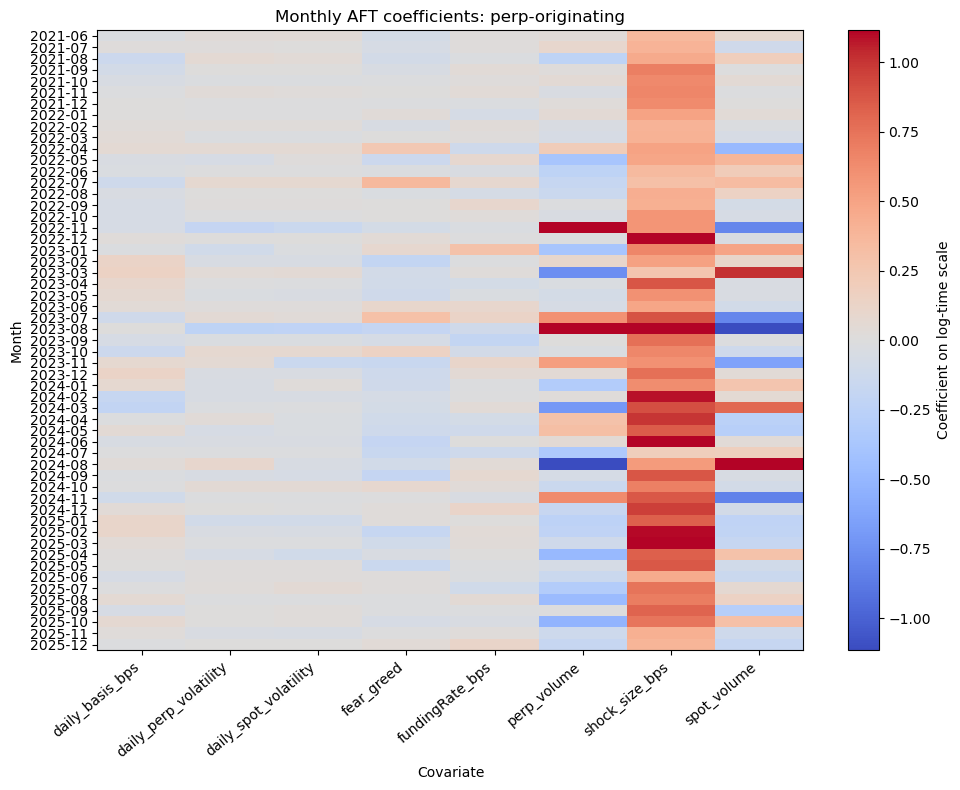

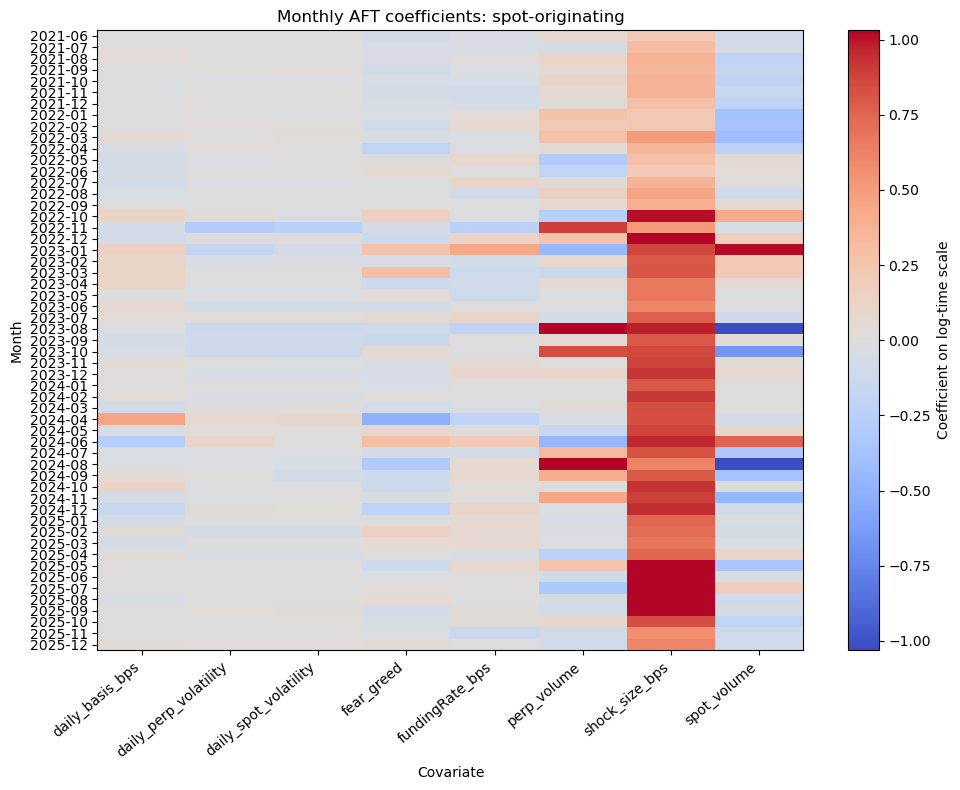

In [33]:
for origin in sorted(coefficients["origin"].unique()):
    fig, ax = plot_coefficient_heatmap(
        coefficients,
        origin=origin,
        output_path=OUTPUT_DIR / f"coefficient_heatmap_{origin}.png",
    )
    plt.show()


For the Log-Logistic AFT model:

- `time_ratio > 1` means a longer modeled resolution time;
- `time_ratio < 1` means a shorter modeled resolution time.

The daily data are cached, so later runs do not download them again unless `overwrite=True`.


Generating figure for BTC linear...


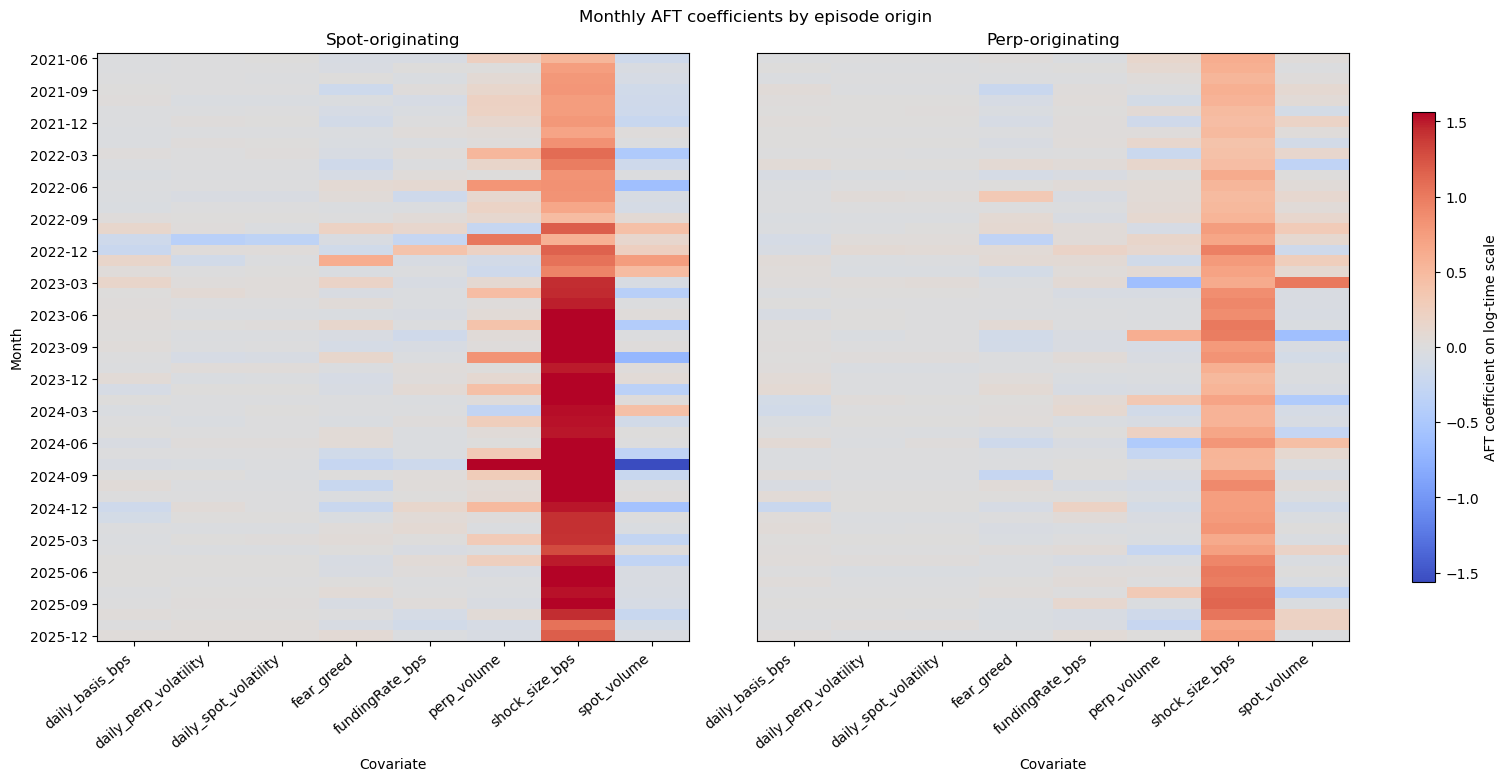

Generating figure for BTC inverse...


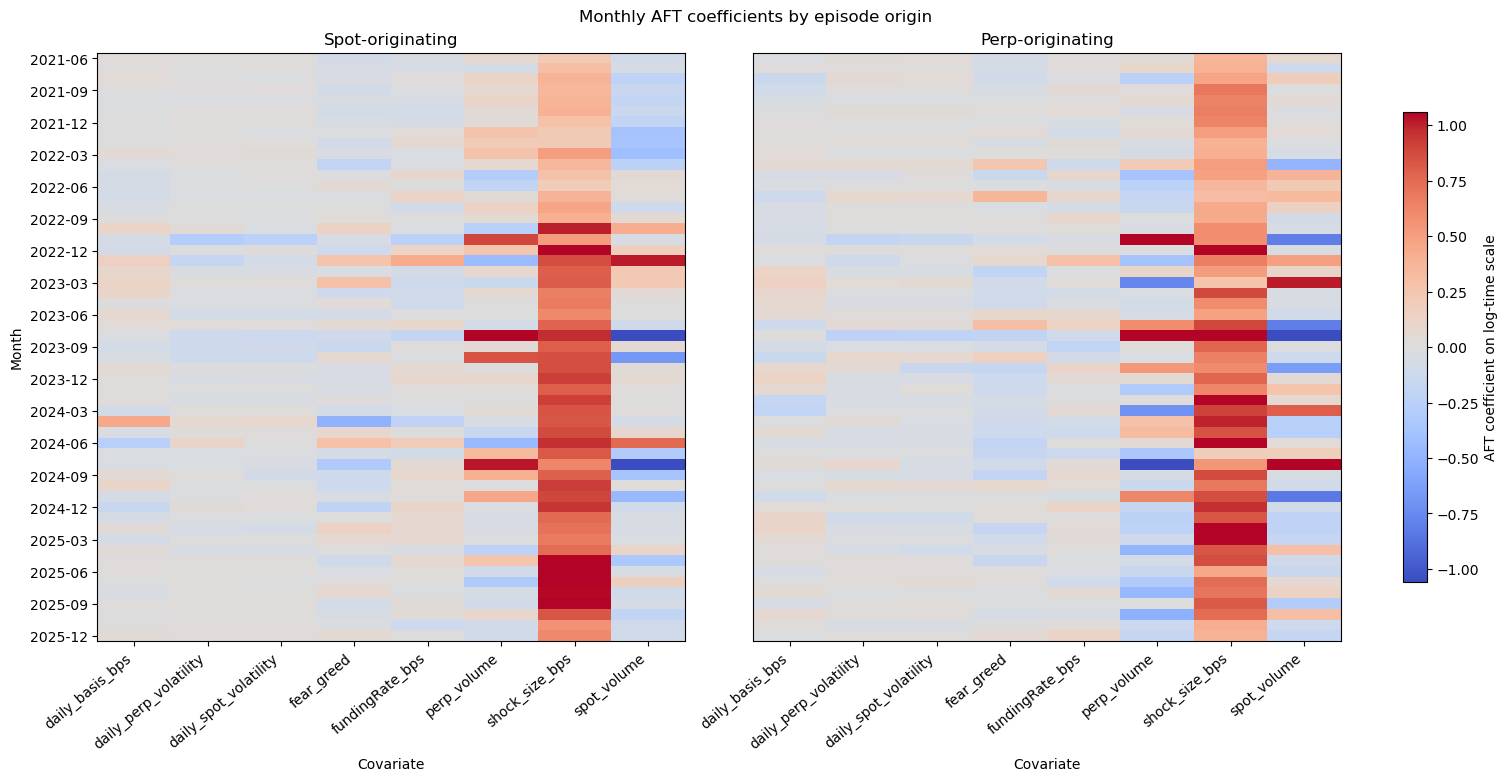

Generating figure for ETH linear...


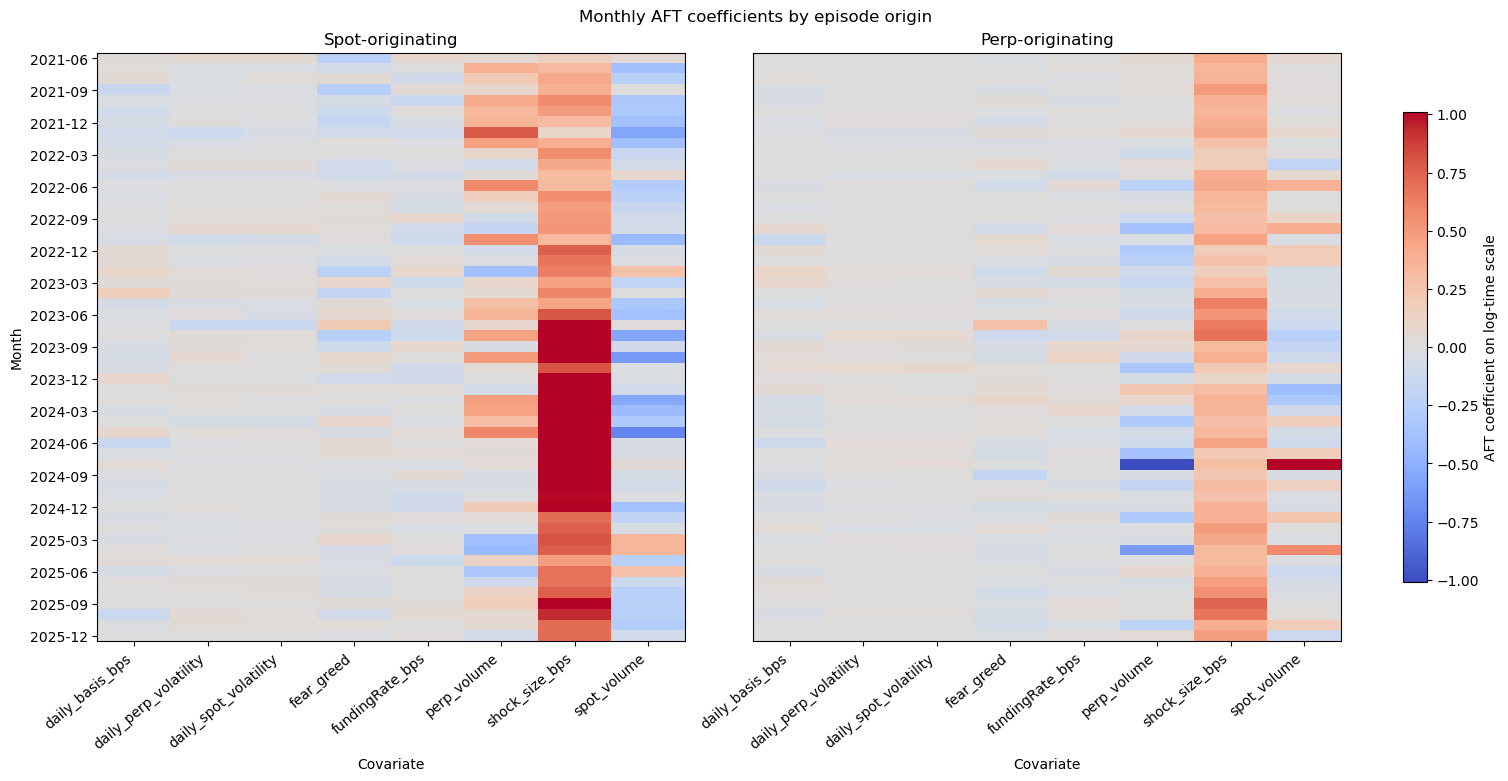

Generating figure for ETH inverse...


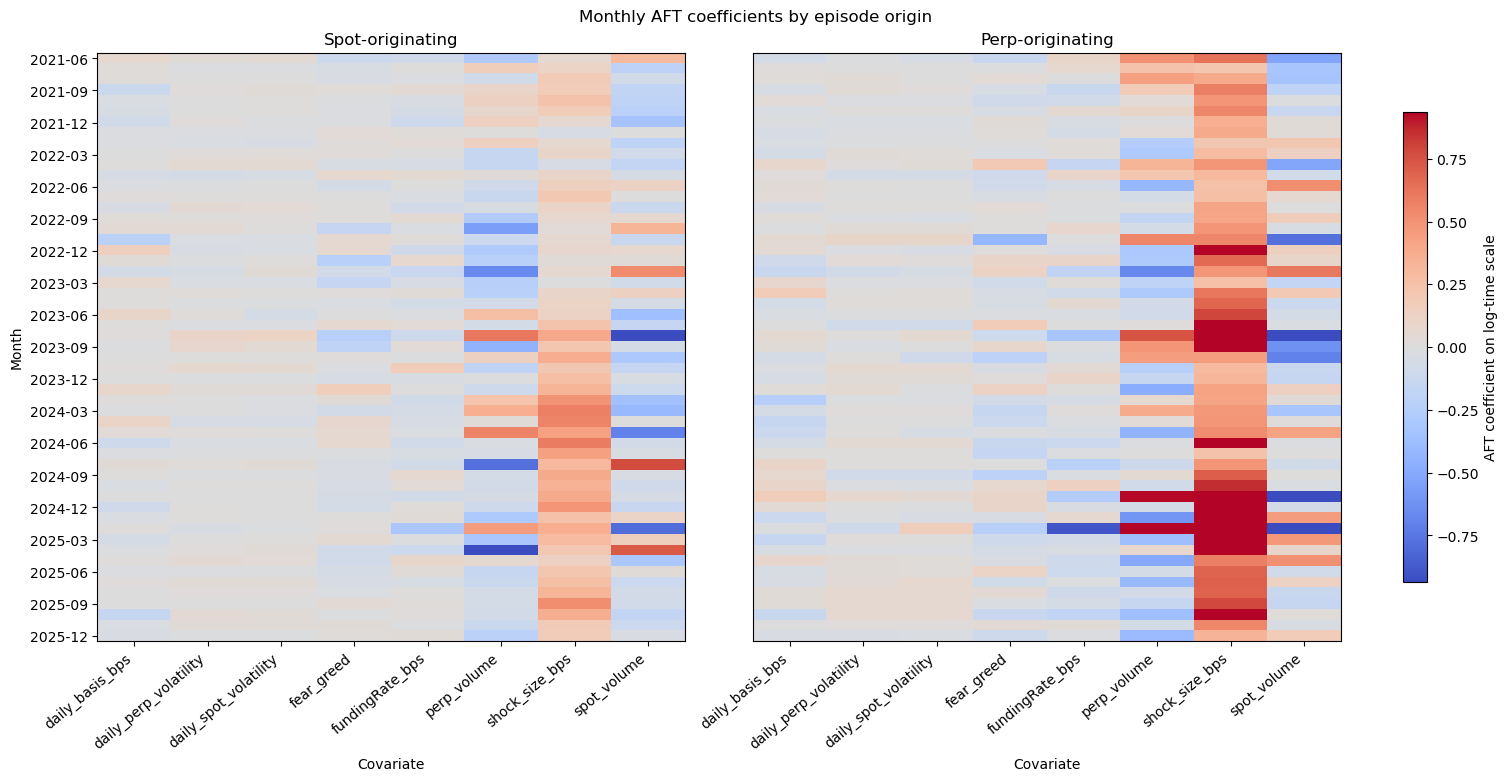

Saved figures to: C:\Users\Julia\OneDrive - University of Toronto\Desktop\School files\4th year\Thesis\Thesis-code\aft_all_figures


In [39]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Set up paths to your four result folders
# -----------------------------------
RESULT_SPECS = [
    {
        "asset": "BTC",
        "contract": "linear",
        "result_dir": Path("./aft_results_btc_um"),
        "filename": "btc_linear_spot_perp_heatmap.png",
        "title": "BTC linear perpetual: monthly AFT coefficients by episode origin",
    },
    {
        "asset": "BTC",
        "contract": "inverse",
        "result_dir": Path("./aft_results_btc_cm"),
        "filename": "btc_inverse_spot_perp_heatmap.png",
        "title": "BTC inverse perpetual: monthly AFT coefficients by episode origin",
    },
    {
        "asset": "ETH",
        "contract": "linear",
        "result_dir": Path("./aft_results_eth_um"),
        "filename": "eth_linear_spot_perp_heatmap.png",
        "title": "ETH linear perpetual: monthly AFT coefficients by episode origin",
    },
    {
        "asset": "ETH",
        "contract": "inverse",
        "result_dir": Path("./aft_results_eth_cm"),
        "filename": "eth_inverse_spot_perp_heatmap.png",
        "title": "ETH inverse perpetual: monthly AFT coefficients by episode origin",
    },
]

FIGURE_OUTPUT_DIR = Path("./aft_all_figures")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------
# Helper wrapper so each figure gets its own title
# -----------------------------------
def plot_spot_perp_heatmaps_one_row_with_title(
    coefficients,
    title,
    output_path=None,
    tick_every=3,
):
    fig, axes = plot_spot_perp_heatmaps_one_row(
        coefficients=coefficients,
        output_path=None,
        tick_every=tick_every,
    )
    fig.suptitle(title)

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            output_path,
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()
    return fig, axes

# -----------------------------------
# Generate all figures
# -----------------------------------
all_loaded_coefficients = {}

for spec in RESULT_SPECS:
    coefficient_path = spec["result_dir"] / "monthly_coefficients.csv"

    if not coefficient_path.exists():
        print(f"Skipping missing file: {coefficient_path}")
        continue

    coefficients = pd.read_csv(coefficient_path)
    all_loaded_coefficients[
        f"{spec['asset'].lower()}_{spec['contract']}"
    ] = coefficients

    print(f"Generating figure for {spec['asset']} {spec['contract']}...")

    fig, axes = plot_spot_perp_heatmaps_one_row_with_title(
        coefficients=coefficients,
        title=spec["title"],
        output_path=FIGURE_OUTPUT_DIR / spec["filename"],
        tick_every=3,   # change to 12 for yearly labels
    )

print(f"Saved figures to: {FIGURE_OUTPUT_DIR.resolve()}")

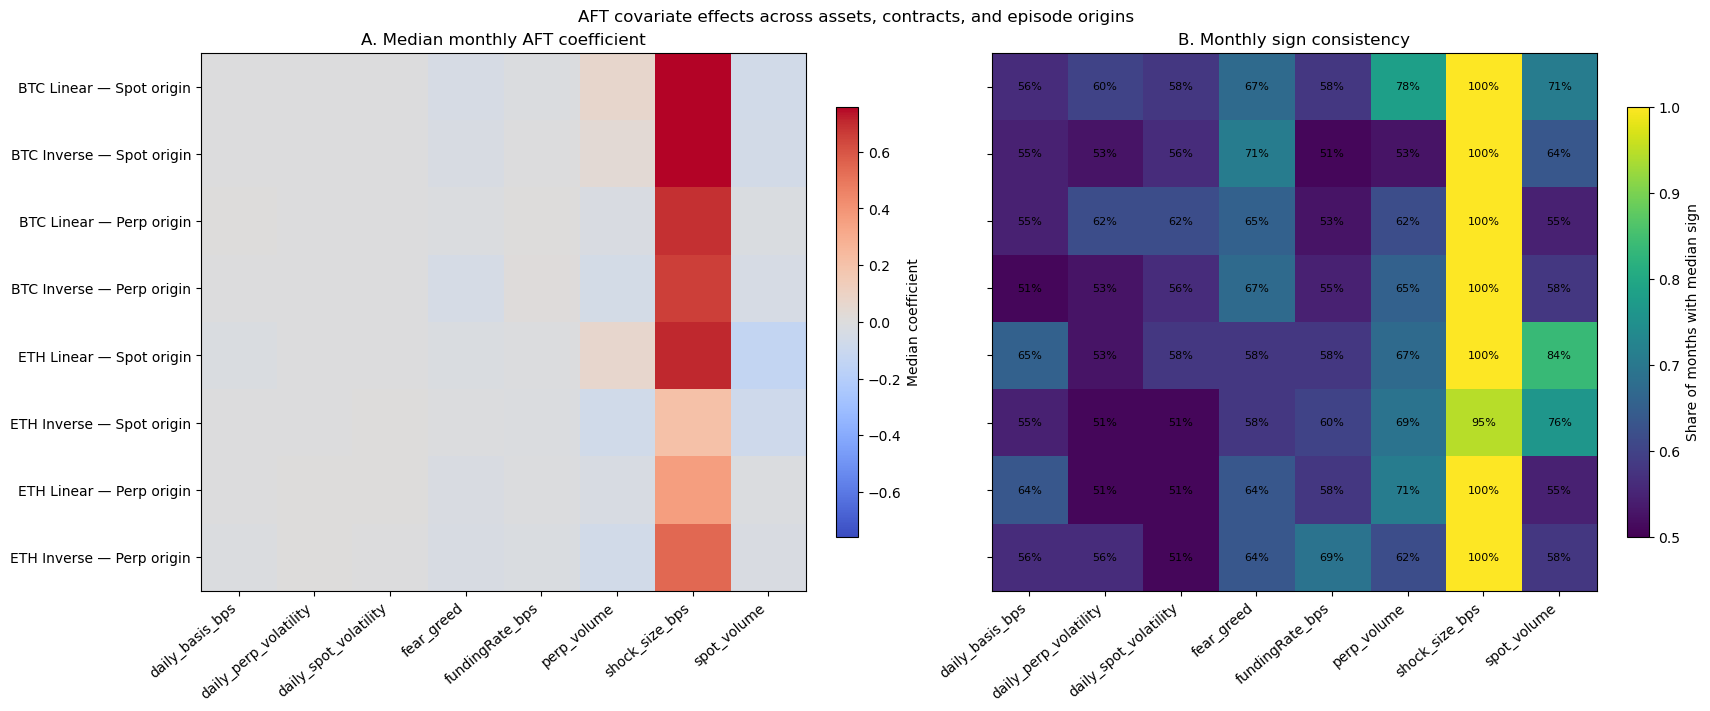

,asset,contract,origin,covariate,time_ratio_summary,sign_consistency,valid_months,median_concordance
0,BTC,Inverse,perp,daily_basis_bps,"0.998 [0.951, 1.043]",50.9%,55,0.580
1,BTC,Inverse,perp,daily_perp_volatility,"0.998 [0.963, 1.018]",52.7%,55,0.580
2,BTC,Inverse,perp,daily_spot_volatility,"0.997 [0.965, 1.017]",56.4%,55,0.580
3,BTC,Inverse,perp,fear_greed,"0.957 [0.905, 1.010]",67.3%,55,0.580
4,BTC,Inverse,perp,fundingRate_bps,"1.007 [0.965, 1.040]",54.5%,55,0.580
...,...,...,...,...,...,...,...,...
59,ETH,Linear,spot,fear_greed,"0.979 [0.933, 1.025]",58.2%,55,0.592
60,ETH,Linear,spot,fundingRate_bps,"0.991 [0.933, 1.013]",58.2%,55,0.592
61,ETH,Linear,spot,perp_volume,"1.065 [0.973, 1.362]",67.3%,55,0.592
62,ETH,Linear,spot,shock_size_bps,"2.025 [1.612, 2.807]",100.0%,55,0.592


Saved comparison outputs to: C:\Users\Julia\OneDrive - University of Toronto\Desktop\School files\4th year\Thesis\Thesis-code\aft_comparison_results


In [37]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

RESULT_DIRS = {
    ("BTC", "Linear"): Path("./aft_results_btc_um"),
    ("BTC", "Inverse"): Path("./aft_results_btc_cm"),
    ("ETH", "Linear"): Path("./aft_results_eth_um"),
    ("ETH", "Inverse"): Path("./aft_results_eth_cm"),
}

COMPARISON_OUTPUT_DIR = Path("./aft_comparison_results")
COMPARISON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set to a number such as 0.55 to exclude models with low concordance.
# Leave as None to retain every successfully fitted monthly model.
MIN_CONCORDANCE = None

# Quarterly labels in appendix figures.
MONTH_TICK_EVERY = 3


# ============================================================
# LOAD ALL FOUR ASSET-CONTRACT RESULTS
# ============================================================

coefficient_frames = []
diagnostic_frames = []

for (asset, contract), result_dir in RESULT_DIRS.items():
    coefficient_path = result_dir / "monthly_coefficients.csv"
    diagnostic_path = result_dir / "monthly_diagnostics.csv"

    if not coefficient_path.exists():
        print(f"Missing coefficient file: {coefficient_path}")
        continue

    coefficients_one = pd.read_csv(coefficient_path)
    coefficients_one["asset"] = asset
    coefficients_one["contract"] = contract
    coefficient_frames.append(coefficients_one)

    if diagnostic_path.exists():
        diagnostics_one = pd.read_csv(diagnostic_path)
        diagnostics_one["asset"] = asset
        diagnostics_one["contract"] = contract
        diagnostic_frames.append(diagnostics_one)


if not coefficient_frames:
    raise FileNotFoundError(
        "No monthly_coefficients.csv files were found."
    )

all_coefficients = pd.concat(
    coefficient_frames,
    ignore_index=True,
)

all_diagnostics = (
    pd.concat(diagnostic_frames, ignore_index=True)
    if diagnostic_frames
    else pd.DataFrame()
)

all_coefficients["period"] = all_coefficients["period"].astype(str)
all_coefficients["origin"] = all_coefficients["origin"].astype(str)
all_coefficients["covariate"] = all_coefficients["covariate"].astype(str)


# ============================================================
# ATTACH MONTHLY MODEL DIAGNOSTICS
# ============================================================

if not all_diagnostics.empty:
    all_diagnostics["period"] = all_diagnostics["period"].astype(str)
    all_diagnostics["origin"] = all_diagnostics["origin"].astype(str)

    diagnostic_columns = [
        col
        for col in [
            "asset",
            "contract",
            "period",
            "origin",
            "fit_status",
            "concordance",
            "AIC",
            "n_episodes",
            "n_resolved",
            "censoring_share",
        ]
        if col in all_diagnostics.columns
    ]

    diagnostics_for_merge = (
        all_diagnostics[diagnostic_columns]
        .drop_duplicates(
            subset=["asset", "contract", "period", "origin"],
            keep="last",
        )
    )

    # Avoid duplicate versions of columns already present in coefficients.
    columns_to_add = [
        col
        for col in diagnostics_for_merge.columns
        if col not in all_coefficients.columns
        or col in ["asset", "contract", "period", "origin"]
    ]

    all_coefficients = all_coefficients.merge(
        diagnostics_for_merge[columns_to_add],
        on=["asset", "contract", "period", "origin"],
        how="left",
    )


# Keep successfully fitted models.
if "fit_status" in all_coefficients.columns:
    all_coefficients = all_coefficients[
        all_coefficients["fit_status"].fillna("complete").eq("complete")
    ].copy()

# Optional fit-quality filter.
if (
    MIN_CONCORDANCE is not None
    and "concordance" in all_coefficients.columns
):
    all_coefficients = all_coefficients[
        all_coefficients["concordance"].ge(MIN_CONCORDANCE)
    ].copy()


# If duplicate coefficient rows exist for the same monthly model,
# reduce them to one observation.
aggregation_rules = {
    "coef": "median",
    "time_ratio": "median",
    "p": "median",
}

for optional_col in [
    "concordance",
    "AIC",
    "n_episodes",
    "n_resolved",
    "censoring_share",
]:
    if optional_col in all_coefficients.columns:
        aggregation_rules[optional_col] = "median"

monthly_coefficients = (
    all_coefficients.groupby(
        [
            "asset",
            "contract",
            "origin",
            "period",
            "covariate",
        ],
        as_index=False,
        observed=True,
    )
    .agg(aggregation_rules)
)


# ============================================================
# 1. BUILD CROSS-CONTRACT SUMMARY
# ============================================================

summary_rows = []

for keys, group in monthly_coefficients.groupby(
    ["asset", "contract", "origin", "covariate"],
    observed=True,
):
    asset, contract, origin, covariate = keys

    median_coef = float(group["coef"].median())
    median_sign = np.sign(median_coef)

    if median_sign == 0:
        same_sign_share = float(
            (np.sign(group["coef"]) == 0).mean()
        )
    else:
        same_sign_share = float(
            (np.sign(group["coef"]) == median_sign).mean()
        )

    row = {
        "asset": asset,
        "contract": contract,
        "origin": origin,
        "covariate": covariate,
        "valid_months": group["period"].nunique(),
        "median_coef": median_coef,
        "median_time_ratio": group["time_ratio"].median(),
        "time_ratio_q25": group["time_ratio"].quantile(0.25),
        "time_ratio_q75": group["time_ratio"].quantile(0.75),
        "same_sign_share": same_sign_share,
        "positive_month_share": (group["coef"] > 0).mean(),
        "negative_month_share": (group["coef"] < 0).mean(),
        "significant_month_share": (
            (group["p"] < 0.05).mean()
            if "p" in group.columns
            else np.nan
        ),
    }

    if "concordance" in group.columns:
        row["median_concordance"] = group["concordance"].median()

    if "censoring_share" in group.columns:
        row["median_censoring_share"] = (
            group["censoring_share"].median()
        )

    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)

summary["row_label"] = (
    summary["asset"]
    + " "
    + summary["contract"]
    + " — "
    + summary["origin"].str.capitalize()
    + " origin"
)

row_order = [
    "BTC Linear — Spot origin",
    "BTC Inverse — Spot origin",
    "BTC Linear — Perp origin",
    "BTC Inverse — Perp origin",
    "ETH Linear — Spot origin",
    "ETH Inverse — Spot origin",
    "ETH Linear — Perp origin",
    "ETH Inverse — Perp origin",
]

covariate_order = list(
    dict.fromkeys(monthly_coefficients["covariate"])
)

summary.to_csv(
    COMPARISON_OUTPUT_DIR / "aft_cross_contract_summary.csv",
    index=False,
)


# ============================================================
# 2. TWO-PANEL SUMMARY HEATMAP
# ============================================================

effect_pivot = summary.pivot_table(
    index="row_label",
    columns="covariate",
    values="median_coef",
    aggfunc="first",
).reindex(
    index=row_order,
    columns=covariate_order,
)

stability_pivot = summary.pivot_table(
    index="row_label",
    columns="covariate",
    values="same_sign_share",
    aggfunc="first",
).reindex(
    index=row_order,
    columns=covariate_order,
)

effect_values = effect_pivot.to_numpy(dtype=float)
finite_effects = np.abs(
    effect_values[np.isfinite(effect_values)]
)

effect_limit = (
    float(np.quantile(finite_effects, 0.98))
    if finite_effects.size
    else 1.0
)
effect_limit = max(effect_limit, 1e-6)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 7),
    constrained_layout=True,
)

effect_image = axes[0].imshow(
    effect_values,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-effect_limit,
    vmax=effect_limit,
)

axes[0].set_title("A. Median monthly AFT coefficient")
axes[0].set_xticks(np.arange(len(covariate_order)))
axes[0].set_xticklabels(
    covariate_order,
    rotation=40,
    ha="right",
)
axes[0].set_yticks(np.arange(len(row_order)))
axes[0].set_yticklabels(row_order)

fig.colorbar(
    effect_image,
    ax=axes[0],
    shrink=0.8,
    label="Median coefficient",
)

stability_image = axes[1].imshow(
    stability_pivot.to_numpy(dtype=float),
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=0.5,
    vmax=1.0,
)

axes[1].set_title("B. Monthly sign consistency")
axes[1].set_xticks(np.arange(len(covariate_order)))
axes[1].set_xticklabels(
    covariate_order,
    rotation=40,
    ha="right",
)
axes[1].set_yticks(np.arange(len(row_order)))
axes[1].set_yticklabels([])

fig.colorbar(
    stability_image,
    ax=axes[1],
    shrink=0.8,
    label="Share of months with median sign",
)

# Annotate the stability panel because the values are easy to interpret.
for row_index in range(len(row_order)):
    for col_index in range(len(covariate_order)):
        value = stability_pivot.iloc[row_index, col_index]

        if pd.notna(value):
            axes[1].text(
                col_index,
                row_index,
                f"{value:.0%}",
                ha="center",
                va="center",
                fontsize=8,
            )

fig.suptitle(
    "AFT covariate effects across assets, contracts, and episode origins"
)

fig.savefig(
    COMPARISON_OUTPUT_DIR
    / "aft_effect_and_stability_summary.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 3. COMPACT TABLE FOR THE PAPER
# ============================================================

compact_table = summary.copy()

compact_table["time_ratio_summary"] = compact_table.apply(
    lambda row: (
        f"{row['median_time_ratio']:.3f} "
        f"[{row['time_ratio_q25']:.3f}, "
        f"{row['time_ratio_q75']:.3f}]"
    ),
    axis=1,
)

compact_table["sign_consistency"] = (
    compact_table["same_sign_share"] * 100
).round(1).astype(str) + "%"

columns_to_keep = [
    "asset",
    "contract",
    "origin",
    "covariate",
    "time_ratio_summary",
    "sign_consistency",
    "valid_months",
]

if "median_concordance" in compact_table.columns:
    compact_table["median_concordance"] = (
        compact_table["median_concordance"].round(3)
    )
    columns_to_keep.append("median_concordance")

compact_table = compact_table[columns_to_keep]

compact_table.to_csv(
    COMPARISON_OUTPUT_DIR / "aft_compact_results_table.csv",
    index=False,
)

display(compact_table)


# ============================================================
# 4. APPENDIX: MONTHLY HEATMAPS FOR EACH ASSET-CONTRACT
# ============================================================

def plot_monthly_origin_heatmaps(
    data,
    asset,
    contract,
    output_path,
    tick_every=3,
):
    subset = data[
        data["asset"].eq(asset)
        & data["contract"].eq(contract)
    ].copy()

    origins = ["spot", "perp"]
    pivots = {}

    for origin in origins:
        pivots[origin] = (
            subset[subset["origin"].eq(origin)]
            .pivot_table(
                index="period",
                columns="covariate",
                values="coef",
                aggfunc="median",
            )
            .sort_index()
        )

    periods = sorted(
        set().union(
            *[pivot.index for pivot in pivots.values()]
        )
    )

    covariates = [
        covariate
        for covariate in covariate_order
        if any(
            covariate in pivot.columns
            for pivot in pivots.values()
        )
    ]

    for origin in origins:
        pivots[origin] = pivots[origin].reindex(
            index=periods,
            columns=covariates,
        )

    all_values = np.concatenate(
        [
            pivot.to_numpy(dtype=float).ravel()
            for pivot in pivots.values()
        ]
    )

    finite_values = np.abs(
        all_values[np.isfinite(all_values)]
    )

    limit = (
        float(np.quantile(finite_values, 0.98))
        if finite_values.size
        else 1.0
    )
    limit = max(limit, 1e-6)

    figure_height = max(6, len(periods) * 0.14)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, figure_height),
        sharey=True,
        constrained_layout=True,
    )

    tick_positions = np.arange(
        0,
        len(periods),
        tick_every,
    )

    image = None

    for panel_index, origin in enumerate(origins):
        ax = axes[panel_index]

        image = ax.imshow(
            pivots[origin].to_numpy(dtype=float),
            aspect="auto",
            interpolation="nearest",
            cmap="coolwarm",
            vmin=-limit,
            vmax=limit,
        )

        ax.set_xticks(np.arange(len(covariates)))
        ax.set_xticklabels(
            covariates,
            rotation=40,
            ha="right",
        )
        ax.set_yticks(tick_positions)
        ax.set_title(f"{origin.capitalize()}-originating")
        ax.set_xlabel("Covariate")

        if panel_index == 0:
            ax.set_yticklabels(
                [periods[position] for position in tick_positions]
            )
            ax.set_ylabel("Month")
        else:
            ax.tick_params(
                axis="y",
                labelleft=False,
                length=0,
            )

    fig.colorbar(
        image,
        ax=axes,
        shrink=0.8,
        label="AFT coefficient",
    )

    fig.suptitle(
        f"{asset} {contract.lower()} perpetual: monthly AFT coefficients"
    )

    fig.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.close(fig)


appendix_dir = COMPARISON_OUTPUT_DIR / "appendix_monthly_heatmaps"
appendix_dir.mkdir(parents=True, exist_ok=True)

for asset, contract in RESULT_DIRS:
    plot_monthly_origin_heatmaps(
        monthly_coefficients,
        asset=asset,
        contract=contract,
        output_path=(
            appendix_dir
            / f"{asset.lower()}_{contract.lower()}_monthly_heatmaps.png"
        ),
        tick_every=MONTH_TICK_EVERY,
    )

print(
    f"Saved comparison outputs to: "
    f"{COMPARISON_OUTPUT_DIR.resolve()}"
)

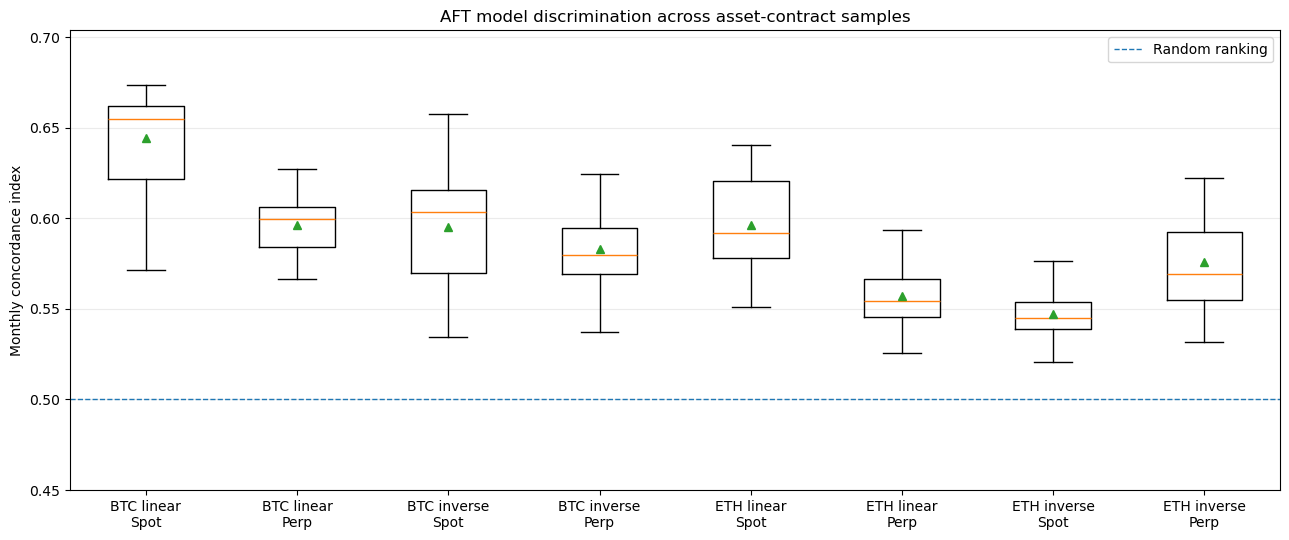

,asset,contract,origin,valid_months,median_concordance,q25_concordance,q75_concordance,minimum_concordance,maximum_concordance
0,BTC,Inverse,perp,55,0.579590,0.569421,0.594664,0.537444,0.645233
1,BTC,Inverse,spot,55,0.603454,0.569659,0.615739,0.534639,0.657736
2,BTC,Linear,perp,55,0.599765,0.584403,0.606115,0.566329,0.627099
3,BTC,Linear,spot,55,0.654798,0.621589,0.661814,0.571262,0.673700
4,ETH,Inverse,perp,55,0.569303,0.554997,0.592443,0.531652,0.670937
5,ETH,Inverse,spot,55,0.545153,0.539088,0.554040,0.513606,0.591262
6,ETH,Linear,perp,55,0.554244,0.545269,0.566449,0.525843,0.610687
7,ETH,Linear,spot,55,0.592032,0.578313,0.620686,0.550862,0.640202


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


RESULT_DIRS = {
    ("BTC", "Linear"): Path("./aft_results_btc_um"),
    ("BTC", "Inverse"): Path("./aft_results_btc_cm"),
    ("ETH", "Linear"): Path("./aft_results_eth_um"),
    ("ETH", "Inverse"): Path("./aft_results_eth_cm"),
}

OUTPUT_DIR = Path("./aft_comparison_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# LOAD MONTHLY DIAGNOSTICS
# ============================================================

diagnostic_frames = []

for (asset, contract), result_dir in RESULT_DIRS.items():
    path = result_dir / "monthly_diagnostics.csv"

    if not path.exists():
        print(f"Missing: {path}")
        continue

    frame = pd.read_csv(path)
    frame["asset"] = asset
    frame["contract"] = contract
    diagnostic_frames.append(frame)

if not diagnostic_frames:
    raise FileNotFoundError(
        "No monthly_diagnostics.csv files were found."
    )

diagnostics_all = pd.concat(
    diagnostic_frames,
    ignore_index=True,
)

diagnostics_all["origin"] = (
    diagnostics_all["origin"]
    .astype(str)
    .str.lower()
)

diagnostics_all["concordance"] = pd.to_numeric(
    diagnostics_all["concordance"],
    errors="coerce",
)

if "fit_status" in diagnostics_all.columns:
    diagnostics_all = diagnostics_all[
        diagnostics_all["fit_status"]
        .fillna("complete")
        .eq("complete")
    ]

diagnostics_all = diagnostics_all.dropna(
    subset=["concordance"]
)


# ============================================================
# ORDER AND LABEL THE EIGHT GROUPS
# ============================================================

group_order = [
    ("BTC", "Linear", "spot"),
    ("BTC", "Linear", "perp"),
    ("BTC", "Inverse", "spot"),
    ("BTC", "Inverse", "perp"),
    ("ETH", "Linear", "spot"),
    ("ETH", "Linear", "perp"),
    ("ETH", "Inverse", "spot"),
    ("ETH", "Inverse", "perp"),
]

group_labels = [
    "BTC linear\nSpot",
    "BTC linear\nPerp",
    "BTC inverse\nSpot",
    "BTC inverse\nPerp",
    "ETH linear\nSpot",
    "ETH linear\nPerp",
    "ETH inverse\nSpot",
    "ETH inverse\nPerp",
]

boxplot_data = []

for asset, contract, origin in group_order:
    values = diagnostics_all.loc[
        diagnostics_all["asset"].eq(asset)
        & diagnostics_all["contract"].eq(contract)
        & diagnostics_all["origin"].eq(origin),
        "concordance",
    ].dropna()

    boxplot_data.append(values.to_numpy())


# ============================================================
# PLOT MONTHLY CONCORDANCE DISTRIBUTIONS
# ============================================================

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.boxplot(
    boxplot_data,
    labels=group_labels,
    showmeans=True,
    meanline=False,
    showfliers=False,
)

# Random-ranking reference.
ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Random ranking",
)

ax.set_ylabel("Monthly concordance index")
ax.set_title(
    "AFT model discrimination across asset-contract samples"
)

ax.set_ylim(
    min(
        0.45,
        diagnostics_all["concordance"].min() - 0.02,
    ),
    min(
        1.0,
        diagnostics_all["concordance"].max() + 0.03,
    ),
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "monthly_concordance_boxplots.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# OPTIONAL: SMALL SUMMARY TABLE FOR APPENDIX OR CAPTION
# ============================================================

concordance_summary = (
    diagnostics_all.groupby(
        ["asset", "contract", "origin"],
        observed=True,
    )
    .agg(
        valid_months=("concordance", "count"),
        median_concordance=("concordance", "median"),
        q25_concordance=(
            "concordance",
            lambda values: values.quantile(0.25),
        ),
        q75_concordance=(
            "concordance",
            lambda values: values.quantile(0.75),
        ),
        minimum_concordance=("concordance", "min"),
        maximum_concordance=("concordance", "max"),
    )
    .reset_index()
)

concordance_summary.to_csv(
    OUTPUT_DIR / "monthly_concordance_summary.csv",
    index=False,
)

display(concordance_summary)